## Get Top Phis and Enrichment

Phi stands for the topic-word distribution of each topic. In essence, each topic is composed of a weighting of all the words in the vocabulary, such that each topic has a "word-topic distribution." Due to the multimodal nature of our model, each one of our topics actually has a word-topic distribution for each type of word (gene, microbe, premiR).

To calculate phi values, we first pass in basis vector $e_{1}, e_{2}, .. e_{k}$ to the decoder and record the decoder output. We then split up the outputs according to the word's type (gene, microbe, premiR), and finally softmax each type to reach word-topic distrbution for each word type.

We perform pathway enrichment analysis by treating the top 20 genes associated with each topic as a gene set, and pass the set into Enrichr (https://maayanlab.cloud/Enrichr/). Recall that from our cluster heatmap of sample latent space, most biologically significant topics learned were topic 6 of our COVID WAE and topic 1 of our CRC WAE, thus we perform enrichment on these topics. Theoretically, we could perform enrichment on any topic's top gene sets.

In [29]:
import sys
sys.path.append('WTM')

import pickle as p
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

import new_ds
from new_ds import mm_Dataset
from WTM_model import WTM
from utils import calc_topic_uniqueness
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
pd.set_option('display.max_rows', None)
import pickle

import seaborn as sns
import time
import dataframe_image as dfi
plt.rcParams['svg.fonttype'] = 'none'

In [11]:
def my_softmax(df):
    
    maxes = df.max(axis=1)
    diffs = df.sub(maxes, axis=0)
    num = np.exp(diffs)
    denom = num.sum(axis=1)
    out = num.div(denom, axis=0)
    return out

def load_model(model_prefix, docSet):
    checkpoint = torch.load(f'WTM_checkpoints/{model_prefix}')
    param = checkpoint["param"]
    model = WTM(**param)
    model.load_model(checkpoint["net"])
    model.id2token = {v: k for k,v in docSet.dictionary.token2id.items()}
    return model

def get_embeds(model, docSet, labels_fname = None):
    embeds = model.get_embed(train_data=docSet, num=1000)

    if labels_fname:
        with open(labels_fname, 'r') as file:
            labels_list = [line.strip() for line in file.readlines()]
        out_df = pd.DataFrame(embeds, index=labels_list)
        return out_df
        
    return pd.DataFrame(embeds)

def calculate_phis(docSet, model):
    out_dict = {}
    all_phi_raw = model.get_topic_word_dist(normalize=False)
    headers = np.concatenate([expmat.columns for expmat in docSet.expmats.values()])
    all_phi_raw = pd.DataFrame(all_phi_raw, columns = headers)
    for data_type in np.unique(docSet.label_type):
        type_raw = all_phi_raw.iloc[:, docSet.label_type==data_type]
        out_dict[data_type] = my_softmax(type_raw)
    return out_dict

In [12]:
ckpts_covid_t10_a5e2 = [f'covid_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]# best one!
ckpts_crc_t10_a5e2 = [f'crc_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_ibd_t10_a5e2 = [f'ibd_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_ibs_t10_a5e2 = [f'ibs_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]

ckpts_crc = [f'crc_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]
ckpts_ibd = [f'ibd_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]
ckpts_ibs = [f'ibs_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]

In [13]:
covid_docSet = mm_Dataset(rebuild=True,
                        data_dir='/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu/privacy_network/covid_data',
                        mode_names=['gene', 'microbeR', 'premiR'],
                        expmat_fnames=['covid_gene.csv', 'covid_microbeR.csv', 'covid_premiR.csv'],
                        metadata_fname='covid_metadata.csv',
                        out_fname='covid_docDataset.pkl',
                        scale='gene'
                       )

crc_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu/privacy_network/crc_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['crc_gene.csv', 'crc_microbeR.csv'],
                        metadata_fname = 'crc_metadata.csv',
                        out_fname = 'crc_docDataset.pkl'
                       )

ibd_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu/privacy_network/ibd_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['ibd_gene.csv', 'ibd_microbeR.csv'],
                        metadata_fname = 'ibd_metadata.csv',
                        out_fname = 'ibd_docDataset.pkl')

ibs_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu/privacy_network/ibs_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['ibs_gene.csv', 'ibs_microbeR.csv'],
                        metadata_fname = 'ibs_metadata.csv',
                        out_fname = 'ibs_docDataset.pkl')

Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding


##### Enrichment for COVID WAE Topic 6 (WikiPathways and KEGG) 

In [31]:
curr_model = load_model(ckpts_covid_t10_a5e2[-1], covid_docSet)
curr_phis = calculate_phis(covid_docSet, curr_model)

top_20s = curr_phis['gene'].iloc[1, :].sort_values(ascending=False).iloc[:20]
top_20s
pd.DataFrame(
    {'Name': [crc_docSet.dictionary[i] for i in top_20s.index.values],
    'Topic Proportion (phi)': top_20s.values}
)

,Name,Topic Proportion (phi)
0,IFNA8,0.003922
1,LRRC20,0.003220
2,LRP1,0.002752
3,NCOR1,0.002693
4,BEND6,0.002436
5,MYOCD,0.001984
6,ZCCHC7,0.001564
7,MOGS,0.001479
8,COA7,0.001419
9,DMTN,0.001328


/tmp/ipykernel_1699457/1306811271.py:34: UserWarning: Glyph 9 (	) missing from current font.
  plt.savefig("bar_of_enrich_covid.svg")
/home/pn269/gibbs_folder/conda_local_envs/m0gnn_gibbs/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


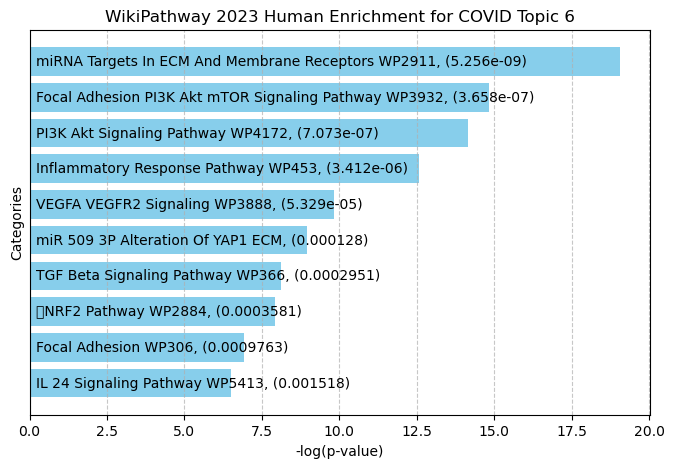

In [14]:
# COVID Topic 6 WikiPathway Enrichments
categories = ['miRNA Targets In ECM And Membrane Receptors WP2911',
              'Focal Adhesion PI3K Akt mTOR Signaling Pathway WP3932',
              'PI3K Akt Signaling Pathway WP4172',
              'Inflammatory Response Pathway WP453',
              'VEGFA VEGFR2 Signaling WP3888',
              'miR 509 3P Alteration Of YAP1 ECM',
              'TGF Beta Signaling Pathway WP366',
              '	NRF2 Pathway WP2884',
              'Focal Adhesion WP306',
              'IL 24 Signaling Pathway WP5413'][::-1]
values = [5.256e-9, 3.658e-7, 7.073e-7, 0.000003412, 0.00005329, 0.0001280, 0.0002951, 0.0003581, 0.0009763, 0.001518][::-1]

plt_vals = [-np.log(val) for val in values]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(categories, plt_vals , color='skyblue', )

# Add text labels on bars
for cat, bar, raw_val in zip(categories, bars, values):
    
    plt.text(0.2, bar.get_y() + bar.get_height()/2, 
             f'{cat}, ({raw_val})',
             va='center', ha='left', fontsize=10, color='black')

# Adding title and labels
plt.yticks([])
plt.xlabel('-log(p-value)')
plt.ylabel('Categories')
plt.title('WikiPathway 2023 Human Enrichment for COVID Topic 6')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("bar_of_enrich_covid.svg")
plt.show()

/tmp/ipykernel_1699457/3087212063.py:34: UserWarning: Glyph 9 (	) missing from current font.
  plt.savefig("bar_of_enrich_kegg_covid.svg")


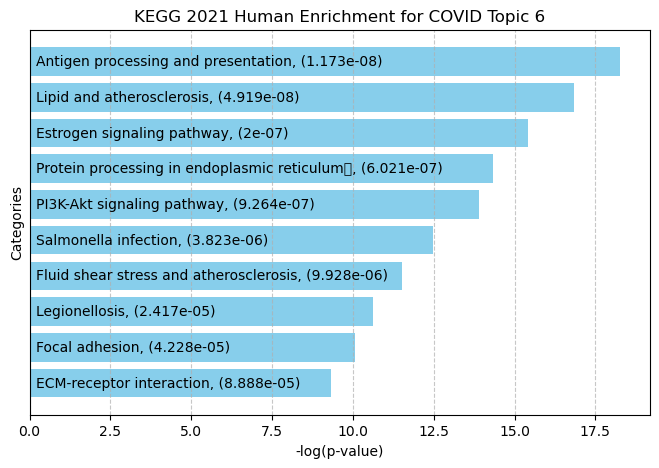

In [15]:
# COVID Topic 6 KEGG 2021 Enrichments
categories = ['Antigen processing and presentation',
              'Lipid and atherosclerosis',
              'Estrogen signaling pathway',
              'Protein processing in endoplasmic reticulum	',
              'PI3K-Akt signaling pathway',
              'Salmonella infection',
              'Fluid shear stress and atherosclerosis',
              'Legionellosis',
              'Focal adhesion',
              'ECM-receptor interaction'][::-1]
values = [1.173e-8	, 4.919e-8, 2.000e-7, 6.021e-7, 9.264e-7, 0.000003823, 0.000009928, 0.00002417, 0.00004228,0.00008888][::-1]

plt_vals = [-np.log(val) for val in values]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(categories, plt_vals , color='skyblue', )

# Add text labels on bars
for cat, bar, raw_val in zip(categories, bars, values):
    
    plt.text(0.2, bar.get_y() + bar.get_height()/2, 
             f'{cat}, ({raw_val})',
             va='center', ha='left', fontsize=10, color='black')

# Adding title and labels
plt.yticks([])
plt.xlabel('-log(p-value)')
plt.ylabel('Categories')
plt.title('KEGG 2021 Human Enrichment for COVID Topic 6')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("bar_of_enrich_kegg_covid.svg")
plt.show()

##### Enrichment for Colorectal Cancer WAE Topic 1 (WikiPathways and KEGG) 

In [32]:
curr_model = load_model(ckpts_crc[-1], crc_docSet)
curr_phis = calculate_phis(crc_docSet, curr_model)

top_20s = curr_phis['gene'].iloc[1, :].sort_values(ascending=False).iloc[:20]
top_20s
pd.DataFrame(
    {'Name': [crc_docSet.dictionary[i] for i in top_20s.index.values],
    'Topic Proportion (phi)': top_20s.values}
)

,Name,Topic Proportion (phi)
0,EEF1A1,0.008008
1,MTRNR2L1,0.005147
2,PIGR,0.004912
3,MUC2,0.003198
4,FAT1,0.002941
5,CEACAM5,0.002830
6,FCGBP,0.002780
7,AHNAK,0.002767
8,ACTB,0.002172
9,SLC12A2,0.002158


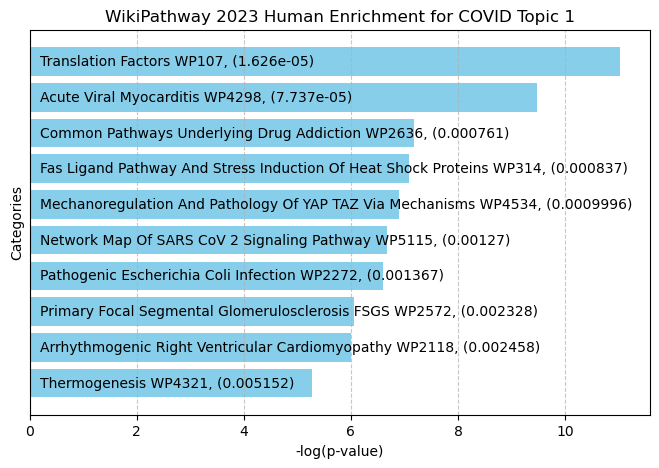

In [16]:
# CRC Topic 6 WikiPathway Enrichments
categories = ['Translation Factors WP107',
              'Acute Viral Myocarditis WP4298',
              'Common Pathways Underlying Drug Addiction WP2636',
              'Fas Ligand Pathway And Stress Induction Of Heat Shock Proteins WP314',
              'Mechanoregulation And Pathology Of YAP TAZ Via Mechanisms WP4534',
              'Network Map Of SARS CoV 2 Signaling Pathway WP5115',
              'Pathogenic Escherichia Coli Infection WP2272',
              'Primary Focal Segmental Glomerulosclerosis FSGS WP2572',
              'Arrhythmogenic Right Ventricular Cardiomyopathy WP2118',
              'Thermogenesis WP4321'][::-1]

values = [0.00001626, 0.00007737, 0.0007610, 0.0008370, 0.0009996, 0.001270, 0.001367, 0.002328, 0.002458, 0.005152][::-1]

plt_vals = [-np.log(val) for val in values]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(categories, plt_vals , color='skyblue', )

# Add text labels on bars
for cat, bar, raw_val in zip(categories, bars, values):
    
    plt.text(0.2, bar.get_y() + bar.get_height()/2, 
             f'{cat}, ({raw_val})',
             va='center', ha='left', fontsize=10, color='black')

# Adding title and labels
plt.yticks([])
plt.xlabel('-log(p-value)')
plt.ylabel('Categories')
plt.title('WikiPathway 2023 Human Enrichment for COVID Topic 1')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("bar_of_enrich_crc.svg")
plt.show()

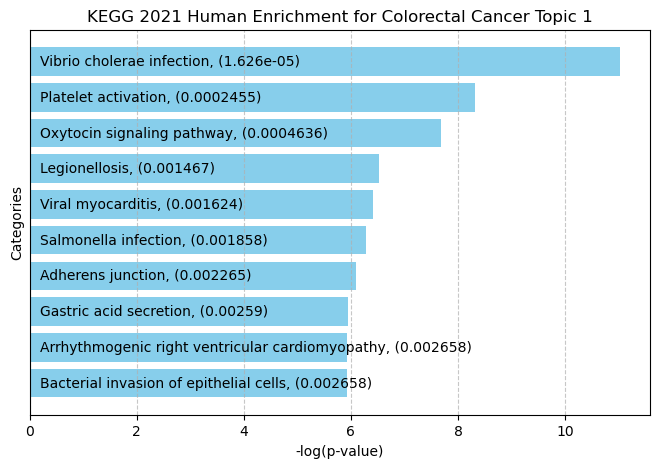

In [17]:
# CRC Topic 6 KEGG Enrichments
categories = ['Vibrio cholerae infection',
             'Platelet activation',
             'Oxytocin signaling pathway',
             'Legionellosis',
             'Viral myocarditis',
             'Salmonella infection',
             'Adherens junction',
             'Gastric acid secretion',
             'Arrhythmogenic right ventricular cardiomyopathy',
             'Bacterial invasion of epithelial cells'][::-1]

values = [0.00001626, 0.0002455, 0.0004636, 0.001467, 0.001624, 0.001858, 0.002265, 0.002590, 0.002658, 0.002658][::-1]

plt_vals = [-np.log(val) for val in values]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.barh(categories, plt_vals , color='skyblue', )

# Add text labels on bars
for cat, bar, raw_val in zip(categories, bars, values):
    
    plt.text(0.2, bar.get_y() + bar.get_height()/2, 
             f'{cat}, ({raw_val})',
             va='center', ha='left', fontsize=10, color='black')

# Adding title and labels
plt.yticks([])
plt.xlabel('-log(p-value)')
plt.ylabel('Categories')
plt.title('KEGG 2021 Human Enrichment for Colorectal Cancer Topic 1')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("bar_of_enrich_kegg_crc.svg")
plt.show()